### The University of Melbourne, School of Computing and Information Systems
# COMP90086 Computer Vision, 2025 Semester 2

## Assigment 3

**Student Name:**    `David Samuel Setiawan`

**Student ID:**     `1676746`

## This iPython notebook is a template which you should use for your Assignment 3 submission. This file should be submitted at the **Assignment 3: Code** link on the LMS.

In addition to this file, you should submit a written report explaining your results at the **Assignment 3: Report** link on the LMS. Please see the assignment specification for details on what must be included in the report for each question.

*Adding proper comments to your code is MANDATORY.*

## Building and Using Autoencoders

Necessary imports

In [1]:
# Imports
import os

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.models import Model

import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version: ", tf.__version__)

2025-10-08 22:46:53.613335: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-08 22:46:53.642280: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-08 22:46:54.239069: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version:  2.20.0


### Load the MNIST training and test data into tensors

In [2]:
(train_images, train_labels), (test_images, test_labels) = keras.datasets.mnist.load_data()

# load the train and test images into tensors and rescale pixel values
train_images = train_images.astype(float) / 255 #scale the pixel values to be 0-1
test_images = test_images.astype(float) / 255

# tranform the input to be a 4D input with batch_shape + (rows, cols, channels) if data_format='channels_last'(default) 

#transform training data
train_images = np.expand_dims(train_images, axis = -1)

#transform testing data
test_images = np.expand_dims(test_images, axis = -1)

#check the shape of each tensor
print("train_images shape:", train_images.shape)
print("test_images shape:", test_images.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
train_images shape: (60000, 28, 28, 1)
test_images shape: (10000, 28, 28, 1)


### Set the number of channels in the latent representation

In [3]:
embedding_size = 16

## Define and train the Autoencoder

### Define the encoder and decoder models and combine to make the whole autoencoder model

In part 3 of the Assignment, you should add your own design(s) for your autoencoders

In [4]:
# Encoder
encoder = keras.Sequential(
    [
        layers.Input((28,28,1)),
        layers.Flatten(),
        layers.Dense(128, activation = 'relu'),
        layers.Dense(embedding_size)
    ]
)

# Decoder
decoder = keras.Sequential(
    [
        layers.Input((embedding_size,)),
        layers.Dense(128, activation='relu'),
        layers.Dense(28*28*1),
        layers.Reshape((28,28,1))
    ]
)

# Autoencoder is encoder followed by decoder
autoencoder = keras.Sequential([encoder,decoder])

### Compile and train the autoencoder

In [5]:
# Configure the model
autoencoder.compile(optimizer='adam',
            loss=tf.keras.losses.MeanSquaredError,
           #loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False), #use SparseCategoricalCrossentropy because labels are integers. If the labels are one-hot representation, please use CategoricalCrossentropy loss.
           metrics=['mse'])

# Start training
# we use train_images as both the input and the target value for our autoencoder (no labels!)
history_autoencoder = autoencoder.fit(train_images, train_images, epochs=200, batch_size=100, validation_split=0.2)

Epoch 1/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0339 - mse: 0.0339 - val_loss: 0.0246 - val_mse: 0.0246
Epoch 2/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0231 - mse: 0.0231 - val_loss: 0.0219 - val_mse: 0.0219
Epoch 3/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0212 - mse: 0.0212 - val_loss: 0.0206 - val_mse: 0.0206
Epoch 4/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0202 - mse: 0.0202 - val_loss: 0.0198 - val_mse: 0.0198
Epoch 5/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0195 - mse: 0.0195 - val_loss: 0.0193 - val_mse: 0.0193
Epoch 6/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0190 - mse: 0.0190 - val_loss: 0.0189 - val_mse: 0.0189
Epoch 7/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0186 - mse: 0.0186 - val_loss: 0.0184 - val_mse: 0.0184
Epoch 8/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0182 - mse: 0.0182 - val_loss: 0.0181 - val_mse: 0.0181
Epoch 9/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/

### Display the training and validation loss curves

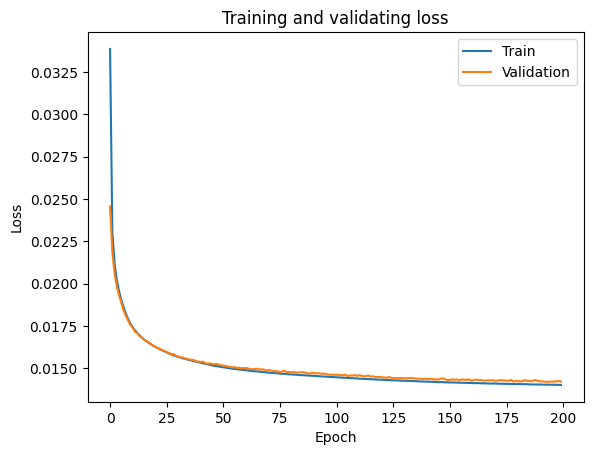

In [6]:
plt.plot(history_autoencoder.history['loss'], label='Train')
plt.plot(history_autoencoder.history['val_loss'], label='Validation')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title('Training and validating loss')
plt.legend()
plt.show()

### Qualitative Evaluation of autoencoder performance

The above graphs show the loss (mean squared error) on the training and validation splits of the training set. We can also observe how the algorithm reconstructs a random sample from the test set.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


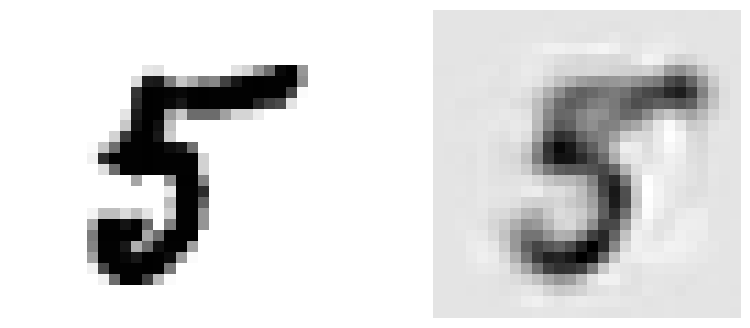

In [7]:
sample_id = np.random.choice(test_images.shape[0])
digit = test_images[sample_id]

# expand dimensions so that it represents a single 'sample'
digit = np.expand_dims(digit, axis=0)

# make a prediction for the test sample
predict_digit = autoencoder.predict(digit)

# make a side by side matplotlib figure
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

ax1.imshow(digit.squeeze(), cmap="binary")
ax1.axis('off')

ax2.imshow(predict_digit.squeeze(), cmap="binary")
ax2.axis('off')

plt.show()

## Building a Classifier from the Autoencoder representations

### Convert the training images into latent embeddings

In [8]:
# transform the training set into latent embeddings
train_embeddings = encoder.predict(train_images)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 426us/step


### Define the classifier
This is a two layer classifier that first projects onto hidden dimensions with relu and then onto the classification space with softmax

In [9]:
classifier = keras.Sequential(
    [
        layers.Input((embedding_size,)),
        layers.Dense(16, activation='relu'),
        layers.Dense(10, activation='softmax')
    ]
)

### Compile and train the classifier
This uses the converted embeddings as input and the labels as target.
Note that the validation_split is 0.999
This means that only 0.001 of the training set is used to train the classifier (60 examples in total)

In [10]:
classifier.compile(optimizer='adam',
           loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
           metrics=['accuracy'])
history_classifier = classifier.fit(train_embeddings, train_labels, epochs=800, batch_size=100, validation_split=0.999)

Epoch 1/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 841ms/step - accuracy: 0.0500 - loss: 2.6438 - val_accuracy: 0.0899 - val_loss: 2.5233
Epoch 2/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.0500 - loss: 2.6333 - val_accuracy: 0.0912 - val_loss: 2.5162
Epoch 3/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.0500 - loss: 2.6230 - val_accuracy: 0.0926 - val_loss: 2.5091
Epoch 4/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - accuracy: 0.0500 - loss: 2.6127 - val_accuracy: 0.0942 - val_loss: 2.5021
Epoch 5/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.0500 - loss: 2.6025 - val_accuracy: 0.0957 - val_loss: 2.4951
Epoch 6/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.0500 - loss: 2.5926 - val_accuracy: 0.0974 - val_loss: 2.4882
Epoch 7/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 0.0500 - loss: 2.5827 - val_accuracy: 0.0990 - val_loss: 2.4814
Epoch 8/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.0500 - loss: 2.5730 - val_accuracy: 0.1007 - v

### Display the training and validation accuracy

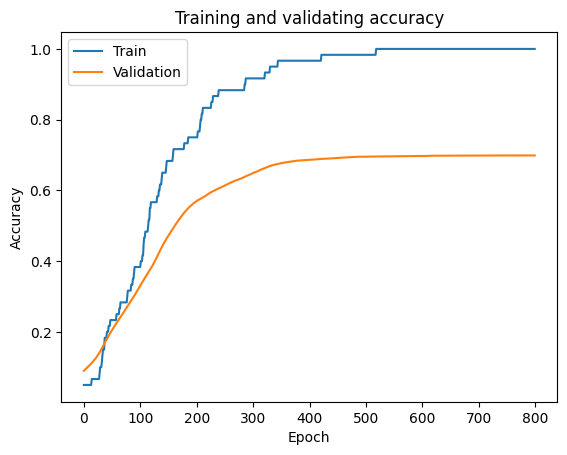

In [11]:
plt.plot(history_classifier.history['accuracy'], label='Train')
plt.plot(history_classifier.history['val_accuracy'], label='Validation')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.title('Training and validating accuracy')
plt.legend()
plt.show()

### Training and valdiation loss

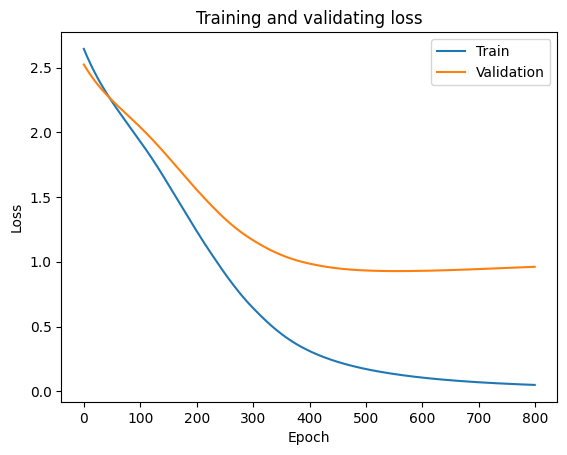

In [12]:
    plt.plot(history_classifier.history['loss'], label='Train')
plt.plot(history_classifier.history['val_loss'], label='Validation')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title('Training and validating loss')
plt.legend()
plt.show()

## Build and Train a conventional baseline classfier

### Create the baseline MLP Classifier from Worksheet 4

In [13]:
# Create the baseline classifier
baseline_classifier = keras.Sequential(
    [
        layers.Input((28,28,1)),               # Tell Keras the shape of the input array (a single-channel 28×28 image)
        layers.Flatten(),                      # Unravel/flatten the input array
        layers.Dense(16, activation='relu'),   # Add a fully-connected layer with 16 units and ReLU activation function as the hidden layer
        layers.Dense(10, activation='softmax') # Add a fully-connected layer with a softmax activation function
    ]
)

### Compile and train the classifier
Again we use a 0.999 validation split so that training only sees 60 examples

In [14]:
baseline_classifier.compile(optimizer='adam',
           loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
           metrics=['accuracy'])
history_baseline_classifier = baseline_classifier.fit(train_images, train_labels, epochs=800, batch_size=100, validation_split=0.999)

Epoch 1/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 841ms/step - accuracy: 0.0833 - loss: 2.2385 - val_accuracy: 0.1179 - val_loss: 2.2692
Epoch 2/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.1167 - loss: 2.1848 - val_accuracy: 0.1395 - val_loss: 2.2466
Epoch 3/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.1500 - loss: 2.1346 - val_accuracy: 0.1584 - val_loss: 2.2257
Epoch 4/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 389ms/step - accuracy: 0.2833 - loss: 2.0855 - val_accuracy: 0.1758 - val_loss: 2.2056
Epoch 5/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.3167 - loss: 2.0376 - val_accuracy: 0.1898 - val_loss: 2.1855
Epoch 6/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.3333 - loss: 1.9900 - val_accuracy: 0.2045 - val_loss: 2.1650
Epoch 7/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.4000 - loss: 1.9434 - val_accuracy: 0.2173 - val_loss: 2.1443
Epoch 8/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.4000 - loss: 1.8970 - val_accuracy: 0.2290 - v

### Display the training and validation accuracy

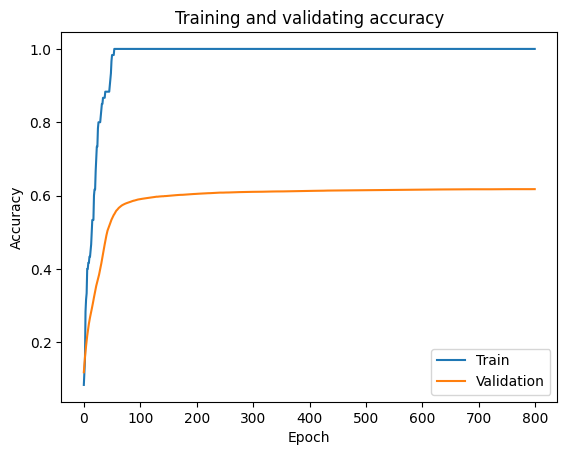

In [15]:
plt.plot(history_baseline_classifier.history['accuracy'], label='Train')
plt.plot(history_baseline_classifier.history['val_accuracy'], label='Validation')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.title('Training and validating accuracy')
plt.legend()
plt.show()

### Training and valdiation loss

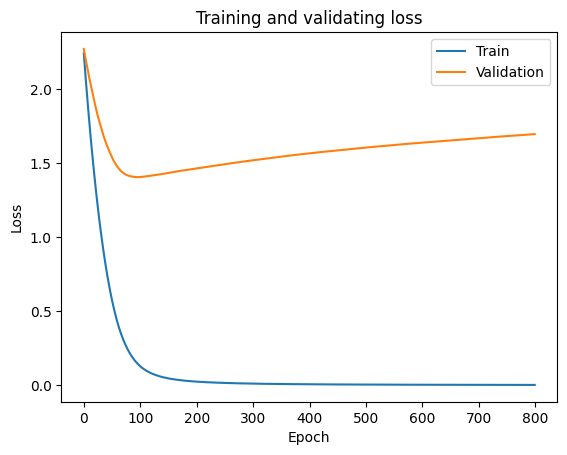

In [16]:
plt.plot(history_baseline_classifier.history['loss'], label='Train')
plt.plot(history_baseline_classifier.history['val_loss'], label='Validation')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title('Training and validating loss')
plt.legend()
plt.show()

## Task 2: Exploring Different Latent Representation Sizes

This section explores the consequences of varying the latent representation size in terms of both the autoencoder reconstruction accuracy and the classifier accuracy.


In [17]:
# Define the latent sizes to explore (at least 5 different sizes)
latent_sizes = [4, 8, 10, 12, 16, 32]

# Dictionary to store results for each latent size
results = {
    'latent_size': [],
    'autoencoder_train_loss': [],
    'autoencoder_val_loss': [],
    'classifier_train_acc': [],
    'classifier_val_acc': []
}

# Loop through each latent size
for embedding_size in latent_sizes:
    print(f"\n{'='*60}")
    print(f"Training with latent size: {embedding_size}")
    print(f"{'='*60}")
    
    # Build the Encoder with current latent size
    encoder_temp = keras.Sequential(
        [
            layers.Input((28,28,1)),
            layers.Flatten(),
            layers.Dense(128, activation='relu'),
            layers.Dense(embedding_size)
        ],
        name=f'encoder_{embedding_size}'
    )
    
    # Build the Decoder with current latent size
    decoder_temp = keras.Sequential(
        [
            layers.Input((embedding_size,)),
            layers.Dense(128, activation='relu'),
            layers.Dense(28*28*1),
            layers.Reshape((28,28,1))
        ],
        name=f'decoder_{embedding_size}'
    )
    
    # Build the Autoencoder
    autoencoder_temp = keras.Sequential([encoder_temp, decoder_temp], name=f'autoencoder_{embedding_size}')
    
    # Compile the autoencoder
    autoencoder_temp.compile(
        optimizer='adam',
        loss=tf.keras.losses.MeanSquaredError(),
        metrics=['mse']
    )
    
    # Train the autoencoder (reduced epochs for faster exploration)
    print("\nTraining Autoencoder...")
    history_ae = autoencoder_temp.fit(
        train_images, 
        train_images, 
        epochs=200,
        batch_size=100,
        validation_split=0.2,
        verbose=0  # Set to 0 to reduce output clutter
    )
    
    # Record autoencoder performance
    final_train_loss = history_ae.history['loss'][-1]
    final_val_loss = history_ae.history['val_loss'][-1]
    print(f"Autoencoder - Final Training Loss: {final_train_loss:.6f}")
    print(f"Autoencoder - Final Validation Loss: {final_val_loss:.6f}")
    
    # Generate embeddings for the classifier
    print("\nGenerating embeddings...")
    train_embeddings_temp = encoder_temp.predict(train_images, verbose=0)
    
    # Build the classifier
    classifier_temp = keras.Sequential(
        [
            layers.Input((embedding_size,)),
            layers.Dense(16, activation='relu'),
            layers.Dense(10, activation='softmax')
        ],
        name=f'classifier_{embedding_size}'
    )
    
    # Compile the classifier
    classifier_temp.compile(
        optimizer='adam',
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=['accuracy']
    )
    
    # Train the classifier
    print("Training Classifier...")
    history_cls = classifier_temp.fit(
        train_embeddings_temp, 
        train_labels,
        epochs=800,
        batch_size=100,
        validation_split=0.999,
        verbose=0  # Set to 0 to reduce output clutter
    )
    
    # Record classifier performance
    final_train_acc = history_cls.history['accuracy'][-1]
    final_val_acc = history_cls.history['val_accuracy'][-1]
    print(f"Classifier - Final Training Accuracy: {final_train_acc:.6f}")
    print(f"Classifier - Final Validation Accuracy: {final_val_acc:.6f}")
    
    # Store results
    results['latent_size'].append(embedding_size)
    results['autoencoder_train_loss'].append(final_train_loss)
    results['autoencoder_val_loss'].append(final_val_loss)
    results['classifier_train_acc'].append(final_train_acc)
    results['classifier_val_acc'].append(final_val_acc)

print(f"\n{'='*60}")
print("Exploration Complete!")
print(f"{'='*60}")



Training with latent size: 4

Training Autoencoder...
Autoencoder - Final Training Loss: 0.028756
Autoencoder - Final Validation Loss: 0.030325

Generating embeddings...
Training Classifier...
Classifier - Final Training Accuracy: 0.900000
Classifier - Final Validation Accuracy: 0.744528

Training with latent size: 8

Training Autoencoder...
Autoencoder - Final Training Loss: 0.021053
Autoencoder - Final Validation Loss: 0.021761

Generating embeddings...
Training Classifier...
Classifier - Final Training Accuracy: 1.000000
Classifier - Final Validation Accuracy: 0.771238

Training with latent size: 10

Training Autoencoder...
Autoencoder - Final Training Loss: 0.018231
Autoencoder - Final Validation Loss: 0.018900

Generating embeddings...
Training Classifier...
Classifier - Final Training Accuracy: 1.000000
Classifier - Final Validation Accuracy: 0.743744

Training with latent size: 12

Training Autoencoder...
Autoencoder - Final Training Loss: 0.016643
Autoencoder - Final Validatio

### Display Results Summary


In [18]:
# Print results in a tabular format
print("\nResults Summary:")
print("="*100)
print(f"{'Latent Size':<15} {'AE Train Loss':<18} {'AE Val Loss':<18} {'Cls Train Acc':<18} {'Cls Val Acc':<18}")
print("="*100)

for i in range(len(results['latent_size'])):
    print(f"{results['latent_size'][i]:<15} "
          f"{results['autoencoder_train_loss'][i]:<18.6f} "
          f"{results['autoencoder_val_loss'][i]:<18.6f} "
          f"{results['classifier_train_acc'][i]:<18.6f} "
          f"{results['classifier_val_acc'][i]:<18.6f}")

print("="*100)

# Identify the best latent size based on classifier validation accuracy
best_idx = np.argmax(results['classifier_val_acc'])
best_latent_size = results['latent_size'][best_idx]
best_val_acc = results['classifier_val_acc'][best_idx]

print(f"\nBest Latent Size: {best_latent_size} with Classifier Validation Accuracy: {best_val_acc:.6f}")



Results Summary:
Latent Size     AE Train Loss      AE Val Loss        Cls Train Acc      Cls Val Acc       
4               0.028756           0.030325           0.900000           0.744528          
8               0.021053           0.021761           1.000000           0.771238          
10              0.018231           0.018900           1.000000           0.743744          
12              0.016643           0.017097           1.000000           0.757257          
16              0.014308           0.014536           1.000000           0.729446          
32              0.009964           0.010059           1.000000           0.611912          

Best Latent Size: 8 with Classifier Validation Accuracy: 0.771238


### Visualize Autoencoder Reconstruction Loss vs Latent Size


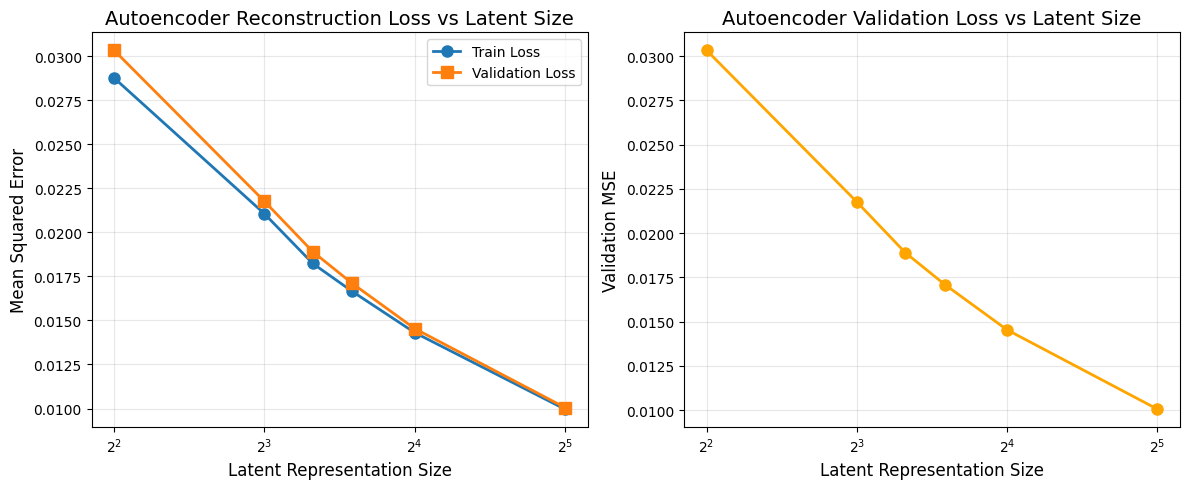

In [19]:
# Plot Autoencoder Loss vs Latent Size
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(results['latent_size'], results['autoencoder_train_loss'], marker='o', label='Train Loss', linewidth=2, markersize=8)
plt.plot(results['latent_size'], results['autoencoder_val_loss'], marker='s', label='Validation Loss', linewidth=2, markersize=8)
plt.xlabel('Latent Representation Size', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.title('Autoencoder Reconstruction Loss vs Latent Size', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xscale('log', base=2)  # Log scale for better visualization

plt.subplot(1, 2, 2)
plt.plot(results['latent_size'], results['autoencoder_val_loss'], marker='o', color='orange', linewidth=2, markersize=8)
plt.xlabel('Latent Representation Size', fontsize=12)
plt.ylabel('Validation MSE', fontsize=12)
plt.title('Autoencoder Validation Loss vs Latent Size', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xscale('log', base=2)

plt.tight_layout()
plt.show()


### Visualize Classifier Accuracy vs Latent Size


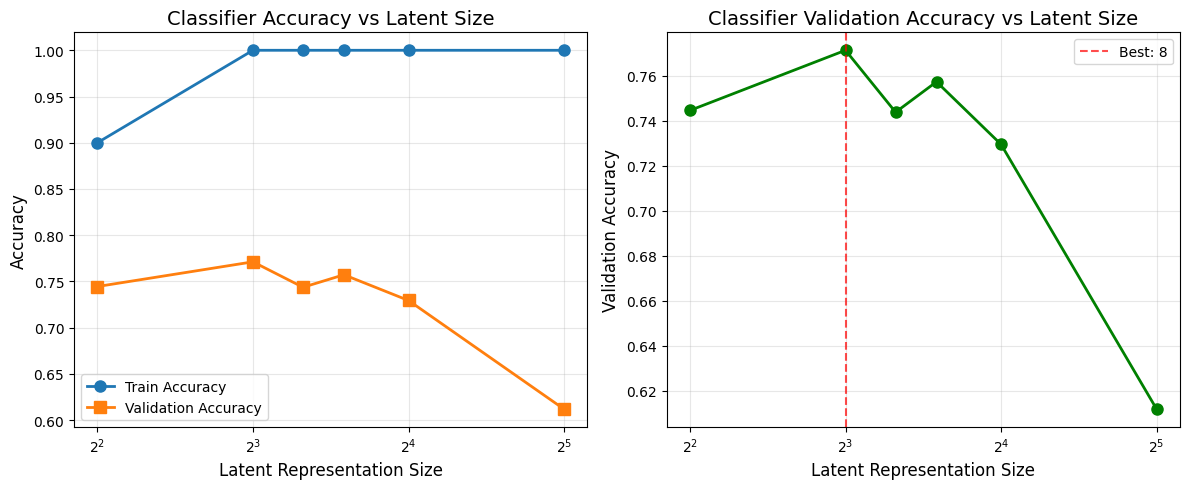

In [20]:
# Plot Classifier Accuracy vs Latent Size
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(results['latent_size'], results['classifier_train_acc'], marker='o', label='Train Accuracy', linewidth=2, markersize=8)
plt.plot(results['latent_size'], results['classifier_val_acc'], marker='s', label='Validation Accuracy', linewidth=2, markersize=8)
plt.xlabel('Latent Representation Size', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Classifier Accuracy vs Latent Size', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xscale('log', base=2)  # Log scale for better visualization

plt.subplot(1, 2, 2)
plt.plot(results['latent_size'], results['classifier_val_acc'], marker='o', color='green', linewidth=2, markersize=8)
plt.xlabel('Latent Representation Size', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.title('Classifier Validation Accuracy vs Latent Size', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xscale('log', base=2)

# Mark the best latent size
best_idx = np.argmax(results['classifier_val_acc'])
plt.axvline(x=results['latent_size'][best_idx], color='red', linestyle='--', alpha=0.7, label=f'Best: {results["latent_size"][best_idx]}')
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()


## Task 3: Improved Autoencoder and Classifier Designs

This section explores different architectural improvements to enhance system performance beyond the baseline 77.1% validation accuracy achieved with 8D MLP autoencoder.


### Experiment 3.1: Convolutional Autoencoder

**Rationale:** Convolutional Neural Networks (CNNs) are fundamentally better suited for image data than Multi-Layer Perceptrons (MLPs) because they:
1. Preserve spatial structure and local patterns
2. Learn hierarchical features (edges → shapes → objects)
3. Have translation equivariance
4. Require fewer parameters than fully-connected layers

**Hypothesis:** CNN-based autoencoder will learn more discriminative features, improving classifier validation accuracy by 3-7% over the 77.1% MLP baseline.


In [3]:
# Experiment 3.1: Convolutional Autoencoder Implementation

# Set embedding size (starting with baseline best: 8D)
embedding_size_cnn = 8

print(f"Experiment 3.1: CNN Autoencoder with {embedding_size_cnn}D latent space")
print("="*60)

# CNN Encoder
cnn_encoder = keras.Sequential([
    layers.Input((28, 28, 1)),
    
    # First convolutional block: 28x28x1 -> 14x14x32
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # Second convolutional block: 14x14x32 -> 7x7x64
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    # Flatten and compress to latent space: 7x7x64 -> embedding_size
    layers.Flatten(),  # 7*7*64 = 3136 features
    layers.Dense(128, activation='relu'),
    layers.Dense(embedding_size_cnn)  # Latent representation
], name='cnn_encoder')

# CNN Decoder
cnn_decoder = keras.Sequential([
    layers.Input((embedding_size_cnn,)),
    
    # Expand from latent space: embedding_size -> 7x7x64
    layers.Dense(128, activation='relu'),
    layers.Dense(7 * 7 * 32, activation='relu'),
    layers.Reshape((7, 7, 32)),
    
    # First deconvolutional block: 7x7x32 -> 14x14x32
    layers.UpSampling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    
    # Second deconvolutional block: 14x14x32 -> 28x28x1
    layers.UpSampling2D((2, 2)),
    layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')  # Output: 28x28x1
], name='cnn_decoder')

# Combined CNN Autoencoder
cnn_autoencoder = keras.Sequential([cnn_encoder, cnn_decoder], name='cnn_autoencoder')

Experiment 3.1: CNN Autoencoder with 8D latent space


I0000 00:00:1759924040.933201 1391173 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 16199 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1759924040.933513 1391173 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 15066 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:02:00.0, compute capability: 8.9


In [23]:
# Train CNN Autoencoder
print("Training CNN Autoencoder...")
print("="*60)

# Compile the CNN autoencoder
cnn_autoencoder.compile(
    optimizer='adam',
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=['mse']
)

# Train the CNN autoencoder
history_cnn_ae = cnn_autoencoder.fit(
    train_images, 
    train_images, 
    epochs=200,
    batch_size=100,
    validation_split=0.2,
    verbose=1
)

# Record CNN autoencoder performance
cnn_ae_train_loss = history_cnn_ae.history['loss'][-1]
cnn_ae_val_loss = history_cnn_ae.history['val_loss'][-1]

print(f"\nCNN Autoencoder Results:")
print(f"Final Training Loss: {cnn_ae_train_loss:.6f}")
print(f"Final Validation Loss: {cnn_ae_val_loss:.6f}")

# Compare with MLP baseline (from Task 2: 8D had val_loss=0.021761)
mlp_baseline_val_loss = 0.021761
improvement_percent = ((mlp_baseline_val_loss - cnn_ae_val_loss) / mlp_baseline_val_loss) * 100
print(f"Improvement over MLP baseline: {improvement_percent:.1f}%")


Training CNN Autoencoder...
Epoch 1/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - loss: 0.0393 - mse: 0.0393 - val_loss: 0.0228 - val_mse: 0.0228
Epoch 2/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - loss: 0.0211 - mse: 0.0211 - val_loss: 0.0200 - val_mse: 0.0200
Epoch 3/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - loss: 0.0192 - mse: 0.0192 - val_loss: 0.0187 - val_mse: 0.0187
Epoch 4/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - loss: 0.0180 - mse: 0.0180 - val_loss: 0.0178 - val_mse: 0.0178
Epoch 5/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - loss: 0.0173 - mse: 0.0173 - val_loss: 0.0172 - val_mse: 0.0172
Epoch 6/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - loss: 0.0167 - mse: 0.0167 - val_loss: 0.0168 - val_mse: 0.0168
Epoch 7/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - loss: 0.0162 - mse: 0.0162 - val_loss: 0.0164 - val_mse: 0.0164
Epoch 8/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - loss: 0.0158 - mse: 0.0158 - val_loss: 0.0161 - val_mse: 0.0161
Epoc

In [24]:
# Generate CNN embeddings and train classifier
print("\nGenerating CNN embeddings...")
cnn_train_embeddings = cnn_encoder.predict(train_images, verbose=0)

# Use the same simple classifier as baseline for fair comparison
cnn_classifier = keras.Sequential([
    layers.Input((embedding_size_cnn,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='cnn_classifier')

# Compile and train the classifier
cnn_classifier.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

print("Training CNN Classifier...")
history_cnn_cls = cnn_classifier.fit(
    cnn_train_embeddings, 
    train_labels,
    epochs=800,
    batch_size=100,
    validation_split=0.999,
    verbose=1
)

# Record CNN classifier performance
cnn_cls_train_acc = history_cnn_cls.history['accuracy'][-1]
cnn_cls_val_acc = history_cnn_cls.history['val_accuracy'][-1]

print(f"\nCNN Classifier Results:")
print(f"Final Training Accuracy: {cnn_cls_train_acc:.6f}")
print(f"Final Validation Accuracy: {cnn_cls_val_acc:.6f}")

# Compare with MLP baseline (from Task 2: 8D had val_acc=0.771238)
mlp_baseline_val_acc = 0.771238
cls_improvement = cnn_cls_val_acc - mlp_baseline_val_acc
print(f"Improvement over MLP baseline: {cls_improvement:+.3f} ({cls_improvement/mlp_baseline_val_acc*100:+.1f}%)")

# Store results for comparison
exp_3_1_results = {
    'name': 'CNN Autoencoder',
    'ae_train_loss': cnn_ae_train_loss,
    'ae_val_loss': cnn_ae_val_loss,
    'cls_train_acc': cnn_cls_train_acc,
    'cls_val_acc': cnn_cls_val_acc
}



Generating CNN embeddings...
Training CNN Classifier...
Epoch 1/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 706ms/step - accuracy: 0.0500 - loss: 3.3694 - val_accuracy: 0.0506 - val_loss: 3.6072
Epoch 2/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 298ms/step - accuracy: 0.0500 - loss: 3.3406 - val_accuracy: 0.0519 - val_loss: 3.5821
Epoch 3/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.0667 - loss: 3.3121 - val_accuracy: 0.0532 - val_loss: 3.5571
Epoch 4/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.0667 - loss: 3.2838 - val_accuracy: 0.0544 - val_loss: 3.5324
Epoch 5/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.0667 - loss: 3.2557 - val_accuracy: 0.0559 - val_loss: 3.5078
Epoch 6/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.0667 - loss: 3.2280 - val_accuracy: 0.0574 - val_loss: 3.4833
Epoch 7/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.0667 - loss: 3.2005 - val_accuracy: 0.0586 - val_loss: 3.4590
Epoch 8/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - a

### Experiment 3.2: CNN Autoencoder with Dropout Regularization

**Rationale:** With only 60 training examples for the classifier, overfitting is a major concern. Dropout regularization:
1. Forces the network to learn more robust, generalizable features
2. Acts like a denoising autoencoder, improving feature quality
3. Reduces the train-validation accuracy gap

**Hypothesis:** Adding dropout will improve generalization, increasing validation accuracy by 2-4% while reducing overfitting.


In [25]:
# Experiment 3.2: CNN Autoencoder with Dropout Regularization

print("Experiment 3.2: CNN Autoencoder with Dropout")
print("="*60)

# CNN Encoder with Dropout
cnn_dropout_encoder = keras.Sequential([
    layers.Input((28, 28, 1)),
    
    # First convolutional block with dropout
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),  # Light dropout after pooling
    
    # Second convolutional block with dropout
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),  # Light dropout after pooling
    
    # Dense layers with heavier dropout
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),  # Heavier dropout before bottleneck
    layers.Dense(embedding_size_cnn)  # No dropout on latent representation
], name='cnn_dropout_encoder')

# CNN Decoder (NO dropout - reconstruction should be precise)
cnn_dropout_decoder = keras.Sequential([
    layers.Input((embedding_size_cnn,)),
    
    # Expand from latent space
    layers.Dense(128, activation='relu'),
    layers.Dense(7 * 7 * 32, activation='relu'),
    layers.Reshape((7, 7, 32)),
    
    # Reconstruction layers (no dropout)
    layers.UpSampling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.UpSampling2D((2, 2)),
    layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')
], name='cnn_dropout_decoder')

# Combined autoencoder
cnn_dropout_autoencoder = keras.Sequential([cnn_dropout_encoder, cnn_dropout_decoder], name='cnn_dropout_autoencoder')

# Compile and train
cnn_dropout_autoencoder.compile(
    optimizer='adam',
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=['mse']
)

print("Training CNN Autoencoder with Dropout...")
history_cnn_dropout_ae = cnn_dropout_autoencoder.fit(
    train_images, 
    train_images, 
    epochs=200,
    batch_size=100,
    validation_split=0.2,
    verbose=1
)

# Record performance
cnn_dropout_ae_train_loss = history_cnn_dropout_ae.history['loss'][-1]
cnn_dropout_ae_val_loss = history_cnn_dropout_ae.history['val_loss'][-1]

print(f"\nCNN Dropout Autoencoder Results:")
print(f"Final Training Loss: {cnn_dropout_ae_train_loss:.6f}")
print(f"Final Validation Loss: {cnn_dropout_ae_val_loss:.6f}")
print(f"vs CNN without dropout: {cnn_ae_val_loss:.6f}")


Experiment 3.2: CNN Autoencoder with Dropout
Training CNN Autoencoder with Dropout...
Epoch 1/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 24s 47ms/step - loss: 0.0533 - mse: 0.0533 - val_loss: 0.0314 - val_mse: 0.0314
Epoch 2/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - loss: 0.0349 - mse: 0.0349 - val_loss: 0.0259 - val_mse: 0.0259
Epoch 3/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - loss: 0.0318 - mse: 0.0318 - val_loss: 0.0242 - val_mse: 0.0242
Epoch 4/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - loss: 0.0304 - mse: 0.0304 - val_loss: 0.0233 - val_mse: 0.0233
Epoch 5/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - loss: 0.0293 - mse: 0.0293 - val_loss: 0.0225 - val_mse: 0.0225
Epoch 6/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - loss: 0.0287 - mse: 0.0287 - val_loss: 0.0218 - val_mse: 0.0218
Epoch 7/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - loss: 0.0281 - mse: 0.0281 - val_loss: 0.0214 - val_mse: 0.0214
Epoch 8/200
480/480 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step - loss: 0.02

In [26]:
# Train classifier with dropout encoder embeddings
print("\nGenerating CNN Dropout embeddings...")
cnn_dropout_train_embeddings = cnn_dropout_encoder.predict(train_images, verbose=0)

# Classifier with dropout regularization
cnn_dropout_classifier = keras.Sequential([
    layers.Input((embedding_size_cnn,)),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.4),  # Add dropout to classifier too
    layers.Dense(10, activation='softmax')
], name='cnn_dropout_classifier')

# Compile and train classifier
cnn_dropout_classifier.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

print("Training CNN Dropout Classifier...")
history_cnn_dropout_cls = cnn_dropout_classifier.fit(
    cnn_dropout_train_embeddings, 
    train_labels,
    epochs=800,
    batch_size=100,
    validation_split=0.999,
    verbose=1
)

# Record classifier performance
cnn_dropout_cls_train_acc = history_cnn_dropout_cls.history['accuracy'][-1]
cnn_dropout_cls_val_acc = history_cnn_dropout_cls.history['val_accuracy'][-1]

print(f"\nCNN Dropout Classifier Results:")
print(f"Final Training Accuracy: {cnn_dropout_cls_train_acc:.6f}")
print(f"Final Validation Accuracy: {cnn_dropout_cls_val_acc:.6f}")

# Compare with previous experiments
print(f"\nComparison:")
print(f"MLP baseline (8D):      {mlp_baseline_val_acc:.3f}")
print(f"CNN (Exp 3.1):          {cnn_cls_val_acc:.3f} ({cnn_cls_val_acc-mlp_baseline_val_acc:+.3f})")
print(f"CNN + Dropout (Exp 3.2): {cnn_dropout_cls_val_acc:.3f} ({cnn_dropout_cls_val_acc-mlp_baseline_val_acc:+.3f})")

# Check for reduced overfitting
overfitting_before = cnn_cls_train_acc - cnn_cls_val_acc
overfitting_after = cnn_dropout_cls_train_acc - cnn_dropout_cls_val_acc
print(f"\nOverfitting analysis (train_acc - val_acc):")
print(f"CNN without dropout: {overfitting_before:.3f}")
print(f"CNN with dropout:    {overfitting_after:.3f}")
print(f"Overfitting reduction: {overfitting_before-overfitting_after:.3f}")

# Store results
exp_3_2_results = {
    'name': 'CNN + Dropout',
    'ae_train_loss': cnn_dropout_ae_train_loss,
    'ae_val_loss': cnn_dropout_ae_val_loss,
    'cls_train_acc': cnn_dropout_cls_train_acc,
    'cls_val_acc': cnn_dropout_cls_val_acc
}



Generating CNN Dropout embeddings...
Training CNN Dropout Classifier...
Epoch 1/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 795ms/step - accuracy: 0.0833 - loss: 11.3070 - val_accuracy: 0.0682 - val_loss: 11.1381
Epoch 2/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.0833 - loss: 12.3503 - val_accuracy: 0.0684 - val_loss: 11.0454
Epoch 3/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.0667 - loss: 9.6996 - val_accuracy: 0.0689 - val_loss: 10.9523
Epoch 4/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.1000 - loss: 12.0764 - val_accuracy: 0.0693 - val_loss: 10.8615
Epoch 5/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.1167 - loss: 11.5249 - val_accuracy: 0.0695 - val_loss: 10.7716
Epoch 6/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.1000 - loss: 9.7209 - val_accuracy: 0.0697 - val_loss: 10.6851
Epoch 7/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.0500 - loss: 11.1971 - val_accuracy: 0.0699 - val_loss: 10.5973
Epoch 8/800
1/1 ━━━━━━━━━━

### Experiment 3.3: Wider Classifier Architecture

**Rationale:** The current classifier uses only 16 hidden units, which might be insufficient to capture complex decision boundaries from the rich CNN features. A wider classifier can:
1. Better exploit the discriminative features learned by the CNN autoencoder
2. Create more complex decision boundaries for better classification
3. Provide more capacity for the small but diverse training set

**Hypothesis:** Increasing classifier capacity from 16 to 64 hidden units will improve validation accuracy by 2-3% without overfitting due to dropout regularization.


In [27]:
# Experiment 3.3: Wider Classifier Architecture

print("Experiment 3.3: Wider Classifier")
print("="*60)

# Use the best autoencoder so far (determine from experiments 3.1 and 3.2)
# For now, let's use the CNN with dropout encoder as it should have the most robust features
best_encoder_so_far = cnn_dropout_encoder
best_embeddings_so_far = cnn_dropout_train_embeddings

# Wider classifier with multiple layers and dropout
wide_classifier = keras.Sequential([
    layers.Input((embedding_size_cnn,)),
    
    # First hidden layer: much wider than baseline (64 vs 16 units)
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),  # Moderate dropout
    
    # Second hidden layer: gradually reduce size
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.3),
    
    # Output layer
    layers.Dense(10, activation='softmax')
], name='wide_classifier')

print("Wide Classifier Architecture:")
wide_classifier.summary()

# Compile and train the wider classifier
wide_classifier.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

print("\nTraining Wider Classifier...")
history_wide_cls = wide_classifier.fit(
    best_embeddings_so_far, 
    train_labels,
    epochs=800,
    batch_size=100,
    validation_split=0.999,
    verbose=1
)

# Record performance
wide_cls_train_acc = history_wide_cls.history['accuracy'][-1]
wide_cls_val_acc = history_wide_cls.history['val_accuracy'][-1]

print(f"\nWide Classifier Results:")
print(f"Final Training Accuracy: {wide_cls_train_acc:.6f}")
print(f"Final Validation Accuracy: {wide_cls_val_acc:.6f}")

# Compare with all previous experiments
print(f"\nComparison (Validation Accuracy):")
print(f"MLP baseline (8D):      {mlp_baseline_val_acc:.3f}")
print(f"CNN (Exp 3.1):          {cnn_cls_val_acc:.3f} ({cnn_cls_val_acc-mlp_baseline_val_acc:+.3f})")
print(f"CNN + Dropout (Exp 3.2): {cnn_dropout_cls_val_acc:.3f} ({cnn_dropout_cls_val_acc-mlp_baseline_val_acc:+.3f})")
print(f"Wide Classifier (Exp 3.3): {wide_cls_val_acc:.3f} ({wide_cls_val_acc-mlp_baseline_val_acc:+.3f})")

# Check for overfitting with wider classifier
wide_overfitting = wide_cls_train_acc - wide_cls_val_acc
narrow_overfitting = cnn_dropout_cls_train_acc - cnn_dropout_cls_val_acc
print(f"\nOverfitting comparison (train_acc - val_acc):")
print(f"Narrow classifier (16 units): {narrow_overfitting:.3f}")
print(f"Wide classifier (64→32 units): {wide_overfitting:.3f}")

# Store results
exp_3_3_results = {
    'name': 'CNN + Dropout + Wide Classifier',
    'ae_train_loss': cnn_dropout_ae_train_loss,  # Same autoencoder
    'ae_val_loss': cnn_dropout_ae_val_loss,
    'cls_train_acc': wide_cls_train_acc,
    'cls_val_acc': wide_cls_val_acc
}


Experiment 3.3: Wider Classifier
Wide Classifier Architecture:


Model: "wide_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_56 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,986 (11.66 KB)

 Trainable params: 2,986 (11.66 KB)

 Non-trainable params: 0 (0.00 B)


Training Wider Classifier...
Epoch 1/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.0167 - loss: 8.0653 - val_accuracy: 0.0425 - val_loss: 6.1240
Epoch 2/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.0500 - loss: 7.6339 - val_accuracy: 0.0433 - val_loss: 5.8568
Epoch 3/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.0833 - loss: 7.9249 - val_accuracy: 0.0446 - val_loss: 5.5938
Epoch 4/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.0833 - loss: 6.3843 - val_accuracy: 0.0458 - val_loss: 5.3419
Epoch 5/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.0500 - loss: 7.1719 - val_accuracy: 0.0476 - val_loss: 5.1063
Epoch 6/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.0833 - loss: 6.9013 - val_accuracy: 0.0500 - val_loss: 4.8818
Epoch 7/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.0667 - loss: 7.8246 - val_accuracy: 0.0525 - val_loss: 4.6692
Epoch 8/800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.1000 - loss: 6.1060

### Experiment 3.4: Optimal Latent Size Search for CNN Architecture

**Rationale:** The optimal latent size might be different for CNN autoencoders compared to MLP autoencoders because:
1. CNNs extract more meaningful spatial features
2. Better feature quality might allow for smaller bottlenecks
3. The CNN architecture might have different capacity-generalization trade-offs

**Hypothesis:** The optimal latent size for CNN architecture will be in the 6-12D range, potentially different from the 8D optimal for MLP.


In [17]:
# Experiment 3.4: Optimal Latent Size Search for CNN Architecture from Exp 3.1

print("Experiment 3.4: Optimal Latent Size Search using CNN Architecture from Exp 3.1")
print("="*70)

# Based on the comparison results, Exp 3.1 (CNN without dropout) performed best
# CNN (Exp 3.1): 0.827 validation accuracy vs baseline 0.771
# We'll now search for the optimal latent size using the EXACT architecture from Exp 3.1

# Test latent sizes with focus on smaller dimensions (CNN features are more efficient)
cnn_latent_sizes = [2, 4, 8, 10, 12, 16]

# Dictionary to store CNN latent size results
cnn_latent_results = {
    'latent_size': [],
    'ae_train_loss': [],
    'ae_val_loss': [],
    'cls_train_acc': [],
    'cls_val_acc': []
}

# Function to create CNN autoencoder using EXACT architecture from Exp 3.1 (NO dropout)
def create_exp_3_1_cnn_autoencoder(latent_dim):
    # CNN Encoder - EXACT same as Exp 3.1 (no dropout)
    encoder = keras.Sequential([
        layers.Input((28, 28, 1)),
        
        # First convolutional block: 28x28x1 -> 14x14x32
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # Second convolutional block: 14x14x32 -> 7x7x64
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        # Flatten and compress to latent space: 7x7x64 -> embedding_size
        layers.Flatten(),  # 7*7*64 = 3136 features
        layers.Dense(128, activation='relu'),
        layers.Dense(latent_dim)  # Latent representation
    ], name=f'exp_3_1_encoder_{latent_dim}d')
    
    # CNN Decoder - EXACT same as Exp 3.1
    decoder = keras.Sequential([
        layers.Input((latent_dim,)),
        
        # Expand from latent space: embedding_size -> 7x7x64
        layers.Dense(128, activation='relu'),
        layers.Dense(7 * 7 * 32, activation='relu'),
        layers.Reshape((7, 7, 32)),
        
        # First deconvolutional block: 7x7x32 -> 14x14x32
        layers.UpSampling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        
        # Second deconvolutional block: 14x14x32 -> 28x28x1
        layers.UpSampling2D((2, 2)),
        layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')  # Output: 28x28x1
    ], name=f'exp_3_1_decoder_{latent_dim}d')
    
    # Combined autoencoder
    autoencoder = keras.Sequential([encoder, decoder], name=f'exp_3_1_autoencoder_{latent_dim}d')
    return encoder, decoder, autoencoder

# Function to create simple classifier (same as used in Exp 3.1)
def create_simple_classifier(latent_dim):
    return keras.Sequential([
        layers.Input((latent_dim,)),
        layers.Dense(16, activation='relu'),  # Same as baseline/Exp 3.1
        layers.Dense(10, activation='softmax')
    ], name=f'simple_classifier_{latent_dim}d')

print(f"Testing {len(cnn_latent_sizes)} latent sizes: {cnn_latent_sizes}")
print("Using EXACT CNN architecture from Exp 3.1 (no dropout, simple classifier)")

Experiment 3.4: Optimal Latent Size Search using CNN Architecture from Exp 3.1
Testing 6 latent sizes: [2, 4, 8, 10, 12, 16]
Using EXACT CNN architecture from Exp 3.1 (no dropout, simple classifier)


In [18]:
# Loop through each latent size using Exp 3.1 CNN architecture
for latent_dim in cnn_latent_sizes:
    print(f"\n{'='*60}")
    print(f"Testing Exp 3.1 CNN with {latent_dim}D latent space")
    print(f"{'='*60}")
    
    # Create models using Exp 3.1 architecture
    encoder_temp, decoder_temp, autoencoder_temp = create_exp_3_1_cnn_autoencoder(latent_dim)
    
    # Compile and train autoencoder
    autoencoder_temp.compile(
        optimizer='adam',
        loss=tf.keras.losses.MeanSquaredError(),
        metrics=['mse']
    )
    
    print(f"Training {latent_dim}D Exp 3.1 CNN Autoencoder...")
    history_ae = autoencoder_temp.fit(
        train_images, 
        train_images, 
        epochs=200,  # Same as original experiments for fair comparison
        batch_size=100,
        validation_split=0.2,
        verbose=0  # Reduce output clutter
    )
    
    # Record autoencoder performance
    final_train_loss = history_ae.history['loss'][-1]
    final_val_loss = history_ae.history['val_loss'][-1]
    print(f"Autoencoder - Train Loss: {final_train_loss:.6f}, Val Loss: {final_val_loss:.6f}")
    
    # Generate embeddings
    train_embeddings_temp = encoder_temp.predict(train_images, verbose=0)
    
    # Create and train simple classifier (same as Exp 3.1)
    classifier_temp = create_simple_classifier(latent_dim)
    classifier_temp.compile(
        optimizer='adam',
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=['accuracy']
    )
    
    print(f"Training {latent_dim}D Simple Classifier...")
    history_cls = classifier_temp.fit(
        train_embeddings_temp, 
        train_labels,
        epochs=800,  # Same as original experiments
        batch_size=100,
        validation_split=0.999,
        verbose=0
    )
    
    # Record classifier performance
    final_train_acc = history_cls.history['accuracy'][-1]
    final_val_acc = history_cls.history['val_accuracy'][-1]
    print(f"Classifier - Train Acc: {final_train_acc:.6f}, Val Acc: {final_val_acc:.6f}")
    mlp_baseline_val_acc = 0.771238
    # Calculate improvement over MLP baseline
    improvement = final_val_acc - mlp_baseline_val_acc
    print(f"Improvement over MLP baseline: {improvement:+.3f} ({improvement/mlp_baseline_val_acc*100:+.1f}%)")
    
    # Store results
    cnn_latent_results['latent_size'].append(latent_dim)
    cnn_latent_results['ae_train_loss'].append(final_train_loss)
    cnn_latent_results['ae_val_loss'].append(final_val_loss)
    cnn_latent_results['cls_train_acc'].append(final_train_acc)
    cnn_latent_results['cls_val_acc'].append(final_val_acc)


Testing Exp 3.1 CNN with 2D latent space
Training 2D Exp 3.1 CNN Autoencoder...
Autoencoder - Train Loss: 0.031224, Val Loss: 0.037669
Training 2D Simple Classifier...
Classifier - Train Acc: 0.800000, Val Acc: 0.662796
Improvement over MLP baseline: -0.108 (-14.1%)

Testing Exp 3.1 CNN with 4D latent space
Training 4D Exp 3.1 CNN Autoencoder...
Autoencoder - Train Loss: 0.020343, Val Loss: 0.026037
Training 4D Simple Classifier...
Classifier - Train Acc: 0.966667, Val Acc: 0.835369
Improvement over MLP baseline: +0.064 (+8.3%)

Testing Exp 3.1 CNN with 8D latent space
Training 8D Exp 3.1 CNN Autoencoder...
Autoencoder - Train Loss: 0.010324, Val Loss: 0.013992
Training 8D Simple Classifier...
Classifier - Train Acc: 1.000000, Val Acc: 0.824725
Improvement over MLP baseline: +0.053 (+6.9%)

Testing Exp 3.1 CNN with 10D latent space
Training 10D Exp 3.1 CNN Autoencoder...
Autoencoder - Train Loss: 0.007840, Val Loss: 0.010886
Training 10D Simple Classifier...
Classifier - Train Acc: 1.

In [20]:
# Display Exp 3.1 CNN Latent Size Search Results
print("\nExp 3.1 CNN Latent Size Search Results:")
print("="*95)
print(f"{'Latent Size':<12} {'AE Val Loss':<13} {'Cls Val Acc':<13} {'vs MLP Baseline':<16} {'vs CNN 8D':<12}")
print("="*95)

# Reference values for comparison
mlp_8d_val_acc = 0.771238  # From Task 2 
cnn_8d_baseline = 0.827     # From Exp 3.1 (as mentioned in user's results)

for i in range(len(cnn_latent_results['latent_size'])):
    latent_size = cnn_latent_results['latent_size'][i]
    ae_val_loss = cnn_latent_results['ae_val_loss'][i]
    cls_val_acc = cnn_latent_results['cls_val_acc'][i]
    improvement_vs_mlp = cls_val_acc - mlp_8d_val_acc
    improvement_vs_cnn_8d = cls_val_acc - cnn_8d_baseline
    
    print(f"{latent_size:<12} {ae_val_loss:<13.6f} {cls_val_acc:<13.6f} {improvement_vs_mlp:+.3f} ({improvement_vs_mlp/mlp_8d_val_acc*100:+4.1f}%) {improvement_vs_cnn_8d:+.3f}")

print("="*95)

# Find optimal latent size for Exp 3.1 CNN architecture
best_cnn_idx = np.argmax(cnn_latent_results['cls_val_acc'])
best_cnn_latent_size = cnn_latent_results['latent_size'][best_cnn_idx]
best_cnn_val_acc = cnn_latent_results['cls_val_acc'][best_cnn_idx]
best_cnn_ae_loss = cnn_latent_results['ae_val_loss'][best_cnn_idx]

print(f"\nOPTIMAL CONFIGURATION FOR EXP 3.1 CNN ARCHITECTURE:")
print(f"Best Latent Size: {best_cnn_latent_size}D")
print(f"Best Validation Accuracy: {best_cnn_val_acc:.6f}")
print(f"Autoencoder Val Loss: {best_cnn_ae_loss:.6f}")
print(f"Improvement over MLP baseline: {best_cnn_val_acc-mlp_8d_val_acc:+.3f} ({(best_cnn_val_acc-mlp_8d_val_acc)/mlp_8d_val_acc*100:+.1f}%)")
print(f"vs Original CNN 8D (Exp 3.1): {best_cnn_val_acc-cnn_8d_baseline:+.3f}")

# Architecture comparison at different latent sizes
print(f"\nCOMPARISON WITH PREVIOUS EXPERIMENTS:")
print(f"MLP baseline (8D):          {mlp_8d_val_acc:.3f}")
print(f"CNN (Exp 3.1, 8D):          {cnn_8d_baseline:.3f} ({cnn_8d_baseline-mlp_8d_val_acc:+.3f})")
print(f"Optimal CNN (Exp 3.4, {best_cnn_latent_size}D): {best_cnn_val_acc:.3f} ({best_cnn_val_acc-mlp_8d_val_acc:+.3f})")



Exp 3.1 CNN Latent Size Search Results:
Latent Size  AE Val Loss   Cls Val Acc   vs MLP Baseline  vs CNN 8D   
2            0.037669      0.662796      -0.108 (-14.1%) -0.164
4            0.026037      0.835369      +0.064 (+8.3%) +0.008
8            0.013992      0.824725      +0.053 (+6.9%) -0.002
10           0.010886      0.818452      +0.047 (+6.1%) -0.009
12           0.008979      0.836486      +0.065 (+8.5%) +0.009
16           0.006651      0.745996      -0.025 (-3.3%) -0.081

OPTIMAL CONFIGURATION FOR EXP 3.1 CNN ARCHITECTURE:
Best Latent Size: 12D
Best Validation Accuracy: 0.836486
Autoencoder Val Loss: 0.008979
Improvement over MLP baseline: +0.065 (+8.5%)
vs Original CNN 8D (Exp 3.1): +0.009

COMPARISON WITH PREVIOUS EXPERIMENTS:
MLP baseline (8D):          0.771
CNN (Exp 3.1, 8D):          0.827 (+0.056)
Optimal CNN (Exp 3.4, 12D): 0.836 (+0.065)
